# HOG + Logistic Regression Processing-Time Evaluation

This notebook evaluates whether the final **HOG + Logistic Regression** pipeline processes one traffic-sign image within **2.000 seconds**.

Unlike the earlier classifier-only timing, this evaluation measures the complete per-image path:

1. Load the image and convert BGR to RGB.
2. Perform traffic-sign ROI segmentation.
3. extract the 1764-dimensional HOG feature vector.
4. Apply the fitted `StandardScaler`.
5. Predict with the final Logistic Regression classifier.

Model training, notebook imports, result tables, plotting and file saving are excluded because they do not occur for each user prediction. One warm-up run is also excluded from the reported measurements. Each of the 84 held-out assignment images is measured three times, one image at a time, using `time.perf_counter()`.


## 1. Imports and project setup


In [1]:
from pathlib import Path
from collections import defaultdict
import platform
import sys
import time

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

# This notebook is intended to be placed in the same notebook folder as
# 01_hog_features_chinese.ipynb and 02_logistic_regression_classifier.ipynb.
sys.path.insert(0, str(Path("..").resolve()))

from pipeline import annotations, features, labels, paths, preprocessing


## 2. Evaluation settings


In [2]:
# Final configuration selected in 02_logistic_regression_classifier.ipynb.
BEST_C = 0.5
SOLVER = "lbfgs"
CLASS_WEIGHT = "balanced"
MAX_ITER = 5000
RANDOM_STATE = 42

# Processing-time requirement and measurement design.
TIME_LIMIT_SECONDS = 2.0
MEASURED_REPEATS = 3

TRAIN_FILE = paths.FEATURE_DIR / "chinese_traffic_signs_hog_features_train.npz"
ASSIGNMENT_FILE = paths.FEATURE_DIR / "assignment1_test_hog_features.npz"
OUTPUT_DIR = paths.RESULT_DIR / "hog_logistic_processing_time"

print(f"Time limit             : {TIME_LIMIT_SECONDS:.3f} seconds per image")
print(f"Measured repeats       : {MEASURED_REPEATS}")
print(f"Final Logistic C       : {BEST_C}")
print(f"Expected HOG dimension : {features.expected_hog_dim()}")


Time limit             : 2.000 seconds per image
Measured repeats       : 3
Final Logistic C       : 0.5
Expected HOG dimension : 1764


### Timing rule

An image passes when its complete end-to-end time is **less than or equal to 2.000 seconds**. The overall system passes only when every expected image is successfully processed and every measured run meets the limit. This deliberately uses the maximum observed runtime as the strictest check; mean, median and 95th-percentile times are also reported.


## 3. Record the test environment


In [3]:
environment_df = pd.DataFrame([
    {
        "Operating System": platform.platform(),
        "Processor": platform.processor() or platform.machine(),
        "Python": platform.python_version(),
        "NumPy": np.__version__,
        "OpenCV": cv2.__version__,
        "scikit-learn": sklearn.__version__,
    }
])

display(environment_df)


,Operating System,Processor,Python,NumPy,OpenCV,scikit-learn
0,Windows-11-10.0.26200-SP0,"Intel64 Family 6 Model 186 Stepping 3, Genuine...",3.14.6,2.4.6,5.0.0,1.9.0


Processing time depends on the computer hardware and software environment. Keep this table with the timing results so another run can be interpreted or reproduced fairly.


## 4. Rebuild the selected final model


In [4]:
if not TRAIN_FILE.exists():
    raise FileNotFoundError(
        f"Training feature file not found: {TRAIN_FILE.resolve()}\n"
        "Run 01_hog_features_chinese.ipynb first."
    )

train_data = np.load(TRAIN_FILE)
X_train = train_data["X"]
y_train = train_data["y"]

expected_dim = features.expected_hog_dim()
if X_train.ndim != 2 or X_train.shape[1] != expected_dim:
    raise ValueError(
        f"Expected HOG feature shape (n, {expected_dim}), received {X_train.shape}."
    )

final_scaler = StandardScaler()
X_train_scaled = final_scaler.fit_transform(X_train)

final_logistic = LogisticRegression(
    C=BEST_C,
    penalty="l2",
    solver=SOLVER,
    class_weight=CLASS_WEIGHT,
    max_iter=MAX_ITER,
    random_state=RANDOM_STATE,
)
final_logistic.fit(X_train_scaled, y_train)

print("Final HOG + Logistic Regression model rebuilt.")
print("Training samples:", X_train.shape[0])
print("HOG features per image:", X_train.shape[1])
print("Classes:", len(final_logistic.classes_))
print("Iterations used:", final_logistic.n_iter_)


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Final HOG + Logistic Regression model rebuilt.
Training samples: 4719
HOG features per image: 1764
Classes: 58
Iterations used: [20]


The model is trained before timing begins. Training time is not part of per-image inference time because the deployed application uses an already-trained model.


## 5. Load the 84 held-out assignment images


In [5]:
if not ASSIGNMENT_FILE.exists():
    raise FileNotFoundError(
        f"Assignment feature file not found: {ASSIGNMENT_FILE.resolve()}\n"
        "Run 01_hog_features_chinese.ipynb first."
    )

assignment_data = np.load(ASSIGNMENT_FILE)
X_assignment_reference = assignment_data["X"]
y_assignment = assignment_data["y"]
assignment_filenames = assignment_data["filenames"].astype(str)

if not (
    len(X_assignment_reference)
    == len(y_assignment)
    == len(assignment_filenames)
):
    raise ValueError("Assignment X, y and filenames are not aligned.")

label_map = labels.load_label_map()

print("Assignment images:", len(assignment_filenames))
print("Reference HOG shape:", X_assignment_reference.shape)
print("Assignment labels:", y_assignment.shape)


Assignment images: 84
Reference HOG shape: (84, 1764)
Assignment labels: (84,)


In [6]:
# Build a basename lookup while retaining every candidate path. This is safer
# than silently overwriting duplicate basenames in a one-path dictionary.
dataset_images = annotations.list_dataset_images()
paths_by_name = defaultdict(list)

for image_path in dataset_images:
    paths_by_name[image_path.name].append(image_path)


def resolve_image_path(saved_filename):
    saved_filename = str(saved_filename)
    basename = Path(saved_filename).name
    candidates = paths_by_name.get(basename, [])

    if len(candidates) == 1:
        return candidates[0]

    if len(candidates) > 1:
        normalized = saved_filename.replace("\\", "/")
        suffix_matches = [
            path for path in candidates
            if path.as_posix().endswith(normalized)
        ]
        if len(suffix_matches) == 1:
            return suffix_matches[0]
        raise ValueError(
            f"Ambiguous filename {saved_filename!r}; candidates: {candidates}"
        )

    raise FileNotFoundError(f"Original image not found: {saved_filename}")


resolved_image_paths = [
    resolve_image_path(filename)
    for filename in assignment_filenames
]

print("Dataset images available:", len(dataset_images))
print("Held-out image paths resolved:", len(resolved_image_paths))
print("All held-out images found:", len(resolved_image_paths) == len(assignment_filenames))


Dataset images available: 5998
Held-out image paths resolved: 84
All held-out images found: True


## 6. Define the full timed pipeline


In [7]:
def process_one_image(image_path):
    # Process one image and return its prediction, HOG vector and stage times.
    # Timed scope: image read/colour conversion -> ROI segmentation -> HOG ->
    # scaling -> single-image Logistic Regression prediction.
    end_to_end_start = time.perf_counter()

    image_bgr = cv2.imread(str(image_path))
    if image_bgr is None:
        raise ValueError(f"OpenCV could not read: {image_path}")
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    load_end = time.perf_counter()

    roi = preprocessing.get_roi(image_rgb)
    segmentation_end = time.perf_counter()
    if roi is None:
        raise ValueError("No traffic-sign ROI was detected")

    roi_rgb, roi_mask = roi
    hog_vector = features.extract_hog_features(roi_rgb, roi_mask)
    hog_end = time.perf_counter()

    if hog_vector is None or hog_vector.shape != (expected_dim,):
        received = None if hog_vector is None else hog_vector.shape
        raise ValueError(f"Invalid HOG vector shape: {received}")
    if not np.all(np.isfinite(hog_vector)):
        raise ValueError("HOG vector contains NaN or infinite values")

    scaled_vector = final_scaler.transform(hog_vector.reshape(1, -1))
    scaling_end = time.perf_counter()

    prediction = int(final_logistic.predict(scaled_vector)[0])
    prediction_end = time.perf_counter()

    return {
        "prediction": prediction,
        "hog_vector": hog_vector,
        "Image Loading Time (s)": load_end - end_to_end_start,
        "ROI Segmentation Time (s)": segmentation_end - load_end,
        "HOG Extraction Time (s)": hog_end - segmentation_end,
        "Feature Scaling Time (s)": scaling_end - hog_end,
        "LR Prediction Time (s)": prediction_end - scaling_end,
        "End-to-End Time (s)": prediction_end - end_to_end_start,
    }


## 7. Warm up once (excluded from results)


In [8]:
# Warm-up avoids counting one-time library initialization and memory allocation
# as though they occur for every deployed prediction.
warm_up_result = process_one_image(resolved_image_paths[0])

print("Warm-up completed and excluded from the measured results.")
print(f"Warm-up end-to-end time: {warm_up_result['End-to-End Time (s)']:.6f} seconds")


Warm-up completed and excluded from the measured results.
Warm-up end-to-end time: 0.048236 seconds


## 8. Measure every image three times


In [9]:
records = []

for trial in range(1, MEASURED_REPEATS + 1):
    for image_index, (image_path, saved_filename, actual, reference_hog) in enumerate(
        zip(
            resolved_image_paths,
            assignment_filenames,
            y_assignment,
            X_assignment_reference,
        ),
        start=1,
    ):
        actual = int(actual)
        attempt_start = time.perf_counter()

        try:
            result = process_one_image(image_path)
            predicted = result["prediction"]
            runtime = result["End-to-End Time (s)"]

            records.append({
                "Trial": trial,
                "Image No.": image_index,
                "Filename": Path(saved_filename).name,
                "Actual Class": actual,
                "Actual Sign": label_map.get(actual, f"Class {actual}"),
                "Predicted Class": predicted,
                "Predicted Sign": label_map.get(predicted, f"Class {predicted}"),
                "Correct": predicted == actual,
                "Status": "Success",
                "Error": "",
                "HOG Matches Saved Features": bool(
                    np.allclose(result["hog_vector"], reference_hog, rtol=1e-5, atol=1e-7)
                ),
                "Within 2 Seconds": runtime <= TIME_LIMIT_SECONDS,
                **{
                    key: result[key]
                    for key in [
                        "Image Loading Time (s)",
                        "ROI Segmentation Time (s)",
                        "HOG Extraction Time (s)",
                        "Feature Scaling Time (s)",
                        "LR Prediction Time (s)",
                        "End-to-End Time (s)",
                    ]
                },
            })

        except Exception as exc:
            failed_time = time.perf_counter() - attempt_start
            records.append({
                "Trial": trial,
                "Image No.": image_index,
                "Filename": Path(saved_filename).name,
                "Actual Class": actual,
                "Actual Sign": label_map.get(actual, f"Class {actual}"),
                "Predicted Class": np.nan,
                "Predicted Sign": "",
                "Correct": False,
                "Status": "Failed",
                "Error": str(exc),
                "HOG Matches Saved Features": False,
                "Within 2 Seconds": False,
                "Image Loading Time (s)": np.nan,
                "ROI Segmentation Time (s)": np.nan,
                "HOG Extraction Time (s)": np.nan,
                "Feature Scaling Time (s)": np.nan,
                "LR Prediction Time (s)": np.nan,
                "End-to-End Time (s)": failed_time,
            })

runtime_runs_df = pd.DataFrame(records)

print("Expected measured runs:", len(assignment_filenames) * MEASURED_REPEATS)
print("Recorded measured runs:", len(runtime_runs_df))
print("Successful runs:", int(runtime_runs_df["Status"].eq("Success").sum()))
print("Failed runs:", int(runtime_runs_df["Status"].eq("Failed").sum()))


Expected measured runs: 252
Recorded measured runs: 252
Successful runs: 252
Failed runs: 0


## 9. Per-image timing results


In [10]:
successful_runs_df = runtime_runs_df.loc[
    runtime_runs_df["Status"].eq("Success")
].copy()

if successful_runs_df.empty:
    raise RuntimeError("No image was processed successfully; inspect the Error column.")

first_success = (
    successful_runs_df
    .sort_values(["Image No.", "Trial"])
    .drop_duplicates("Image No.")
    .set_index("Image No.")
)

time_columns = [
    "Image Loading Time (s)",
    "ROI Segmentation Time (s)",
    "HOG Extraction Time (s)",
    "Feature Scaling Time (s)",
    "LR Prediction Time (s)",
    "End-to-End Time (s)",
]

per_image_times = successful_runs_df.groupby("Image No.")[time_columns].agg(["mean", "max"])
per_image_times.columns = [
    f"{column.replace(' Time (s)', '')} {stat.title()} Time (s)"
    for column, stat in per_image_times.columns
]

per_image_df = first_success[[
    "Filename",
    "Actual Class",
    "Actual Sign",
    "Predicted Class",
    "Predicted Sign",
    "Correct",
]].join(per_image_times)

per_image_pass = runtime_runs_df.groupby("Image No.").agg(
    Successful_Runs=("Status", lambda values: int(values.eq("Success").sum())),
    All_Runs_Within_2_Seconds=("Within 2 Seconds", "all"),
    HOG_Matched_Every_Run=("HOG Matches Saved Features", "all"),
)

per_image_df = per_image_df.join(per_image_pass).reset_index()

display(
    per_image_df.style.format({
        column: "{:.6f}"
        for column in per_image_df.columns
        if column.endswith("Time (s)")
    })
)


,Image No.,Filename,Actual Class,Actual Sign,Predicted Class,Predicted Sign,Correct,Image Loading Mean Time (s),Image Loading Max Time (s),ROI Segmentation Mean Time (s),ROI Segmentation Max Time (s),HOG Extraction Mean Time (s),HOG Extraction Max Time (s),Feature Scaling Mean Time (s),Feature Scaling Max Time (s),LR Prediction Mean Time (s),LR Prediction Max Time (s),End-to-End Mean Time (s),End-to-End Max Time (s),Successful_Runs,All_Runs_Within_2_Seconds,HOG_Matched_Every_Run
0,1,001_0004.png,1,Speed limit fifteen kilometers per hour,1,Speed limit fifteen kilometers per hour,True,0.000848,0.001040,0.003964,0.004326,0.004493,0.005838,0.000756,0.000995,0.001401,0.001443,0.011461,0.012973,3,True,True
1,2,002_0036.png,2,Speed limit thirty kilometers per hour,2,Speed limit thirty kilometers per hour,True,0.003788,0.004721,0.019918,0.021043,0.005791,0.006198,0.000791,0.000987,0.001400,0.001562,0.031689,0.034269,3,True,True
2,3,005_0030.png,5,Speed limit sixty kilometers per hour,5,Speed limit sixty kilometers per hour,True,0.001566,0.001673,0.014538,0.015063,0.004611,0.005424,0.002427,0.005214,0.001381,0.001542,0.024523,0.027414,3,True,True
3,4,020_0003.png,20,Go straight or right,20,Go straight or right,True,0.002351,0.002733,0.019284,0.021130,0.005107,0.005874,0.000814,0.000873,0.001456,0.001776,0.029011,0.031200,3,True,True
4,5,020_0004.png,20,Go straight or right,20,Go straight or right,True,0.002203,0.002528,0.014068,0.014786,0.005310,0.005691,0.000820,0.000911,0.001415,0.001503,0.023816,0.025337,3,True,True
5,6,020_0006.png,20,Go straight or right,20,Go straight or right,True,0.003956,0.004642,0.034100,0.036542,0.005012,0.006666,0.000665,0.000689,0.001341,0.001417,0.045074,0.049895,3,True,True
6,7,021_0003.png,21,Go straight,21,Go straight,True,0.001696,0.001880,0.006833,0.008119,0.003921,0.003979,0.000648,0.000677,0.001281,0.001363,0.014380,0.015790,3,True,True
7,8,021_0002_j.png,21,Go straight,21,Go straight,True,0.001642,0.001653,0.010247,0.010610,0.003995,0.004313,0.000696,0.000782,0.001210,0.001371,0.017790,0.017950,3,True,True
8,9,027_0002.png,27,Roundabout mandatory,27,Roundabout mandatory,True,0.002066,0.002180,0.011273,0.011709,0.003956,0.003975,0.000618,0.000670,0.001262,0.001385,0.019174,0.019672,3,True,True
9,10,031_0011.png,31,Uturn allowed,31,Uturn allowed,True,0.001821,0.001859,0.007940,0.008245,0.004253,0.004596,0.000798,0.000898,0.001269,0.001529,0.016081,0.017071,3,True,True


## 10. Stage-by-stage processing-time summary


In [11]:
stage_columns = time_columns[:-1]

stage_summary_df = pd.DataFrame({
    "Stage": [column.replace(" Time (s)", "") for column in stage_columns],
    "Mean Time (s)": [successful_runs_df[column].mean() for column in stage_columns],
    "Median Time (s)": [successful_runs_df[column].median() for column in stage_columns],
    "95th Percentile (s)": [successful_runs_df[column].quantile(0.95) for column in stage_columns],
    "Maximum Time (s)": [successful_runs_df[column].max() for column in stage_columns],
})

mean_end_to_end = successful_runs_df["End-to-End Time (s)"].mean()
stage_summary_df["Mean Share of End-to-End (%)"] = (
    stage_summary_df["Mean Time (s)"] / mean_end_to_end * 100
)

display(
    stage_summary_df.style.format({
        "Mean Time (s)": "{:.6f}",
        "Median Time (s)": "{:.6f}",
        "95th Percentile (s)": "{:.6f}",
        "Maximum Time (s)": "{:.6f}",
        "Mean Share of End-to-End (%)": "{:.2f}",
    })
)


,Stage,Mean Time (s),Median Time (s),95th Percentile (s),Maximum Time (s),Mean Share of End-to-End (%)
0,Image Loading,0.002061,0.001875,0.004307,0.005157,10.01
1,ROI Segmentation,0.011998,0.010187,0.025971,0.037945,58.30
2,HOG Extraction,0.004535,0.004219,0.005941,0.007266,22.03
3,Feature Scaling,0.000721,0.000657,0.001047,0.005214,3.50
4,LR Prediction,0.001266,0.001234,0.001614,0.001997,6.15


## 11. Final 2-second requirement evaluation


In [12]:
expected_runs = len(assignment_filenames) * MEASURED_REPEATS
successful_run_count = int(runtime_runs_df["Status"].eq("Success").sum())
failed_run_count = expected_runs - successful_run_count
within_limit_count = int(runtime_runs_df["Within 2 Seconds"].sum())

end_to_end_times = successful_runs_df["End-to-End Time (s)"]
mean_time = end_to_end_times.mean()
median_time = end_to_end_times.median()
p95_time = end_to_end_times.quantile(0.95)
maximum_time = end_to_end_times.max()

all_expected_runs_completed = (
    len(runtime_runs_df) == expected_runs
    and failed_run_count == 0
)
all_runs_within_limit = bool(runtime_runs_df["Within 2 Seconds"].all())
all_hog_vectors_match = bool(runtime_runs_df["HOG Matches Saved Features"].all())

requirement_passed = all_expected_runs_completed and all_runs_within_limit

first_trial_df = runtime_runs_df.loc[runtime_runs_df["Trial"].eq(1)].copy()
first_trial_success = first_trial_df["Status"].eq("Success")

if first_trial_success.all():
    pipeline_accuracy = accuracy_score(
        first_trial_df["Actual Class"].astype(int),
        first_trial_df["Predicted Class"].astype(int),
    )
else:
    pipeline_accuracy = np.nan

summary_df = pd.DataFrame([
    {
        "Feature": "HOG",
        "Classifier": "Logistic Regression",
        "Number of Images": len(assignment_filenames),
        "Repeats per Image": MEASURED_REPEATS,
        "Measured Runs": len(runtime_runs_df),
        "Successful Runs": successful_run_count,
        "Failed Runs": failed_run_count,
        "Time Limit (s)": TIME_LIMIT_SECONDS,
        "Mean End-to-End Time (s)": mean_time,
        "Median End-to-End Time (s)": median_time,
        "95th Percentile Time (s)": p95_time,
        "Maximum End-to-End Time (s)": maximum_time,
        "Runs Within Limit": within_limit_count,
        "Runs Within Limit (%)": within_limit_count / expected_runs * 100,
        "Pipeline Accuracy": pipeline_accuracy,
        "All HOG Vectors Match Saved Features": all_hog_vectors_match,
        "Overall Verdict": "PASS" if requirement_passed else "FAIL",
    }
])

display(
    summary_df.style.format({
        "Time Limit (s)": "{:.3f}",
        "Mean End-to-End Time (s)": "{:.6f}",
        "Median End-to-End Time (s)": "{:.6f}",
        "95th Percentile Time (s)": "{:.6f}",
        "Maximum End-to-End Time (s)": "{:.6f}",
        "Runs Within Limit (%)": "{:.2f}",
        "Pipeline Accuracy": "{:.4f}",
    })
)

print("\n2-SECOND PROCESSING-TIME VERDICT")
print("--------------------------------")
print(f"Mean end-to-end time   : {mean_time:.6f} seconds")
print(f"Median end-to-end time : {median_time:.6f} seconds")
print(f"95th-percentile time   : {p95_time:.6f} seconds")
print(f"Maximum time           : {maximum_time:.6f} seconds")
print(f"Runs within 2 seconds  : {within_limit_count}/{expected_runs}")
print(f"Final verdict          : {'PASS' if requirement_passed else 'FAIL'}")


,Feature,Classifier,Number of Images,Repeats per Image,Measured Runs,Successful Runs,Failed Runs,Time Limit (s),Mean End-to-End Time (s),Median End-to-End Time (s),95th Percentile Time (s),Maximum End-to-End Time (s),Runs Within Limit,Runs Within Limit (%),Pipeline Accuracy,All HOG Vectors Match Saved Features,Overall Verdict
0,HOG,Logistic Regression,84,3,252,252,0,2.000,0.020581,0.018475,0.037375,0.050595,252,100.00,1.0000,True,PASS



2-SECOND PROCESSING-TIME VERDICT
--------------------------------
Mean end-to-end time   : 0.020581 seconds
Median end-to-end time : 0.018475 seconds
95th-percentile time   : 0.037375 seconds
Maximum time           : 0.050595 seconds
Runs within 2 seconds  : 252/252
Final verdict          : PASS


The maximum time is used for the final pass/fail decision because the requirement applies to each image, not merely to the average image. The HOG-match check confirms that the features extracted during this live pipeline are consistent with the saved HOG feature file used in the classifier notebook.


## 12. Visualize the timing results


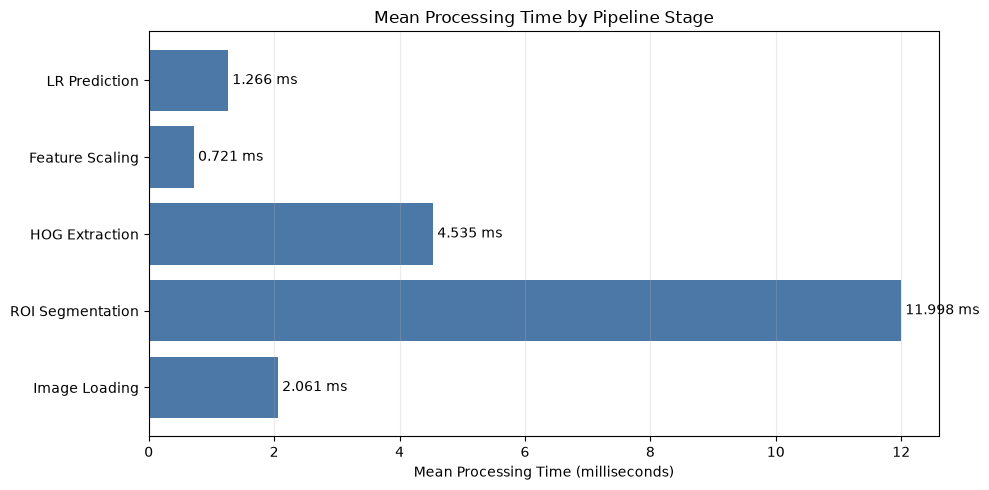

In [13]:
# Figure 1: Mean time used by each processing stage.
stage_plot_df = stage_summary_df.copy()
stage_plot_df["Mean Time (ms)"] = stage_plot_df["Mean Time (s)"] * 1000

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(stage_plot_df["Stage"], stage_plot_df["Mean Time (ms)"], color="#4C78A8")
ax.set_xlabel("Mean Processing Time (milliseconds)")
ax.set_title("Mean Processing Time by Pipeline Stage")
ax.grid(axis="x", alpha=0.25)
ax.bar_label(bars, fmt="%.3f ms", padding=3)
plt.tight_layout()
plt.show()


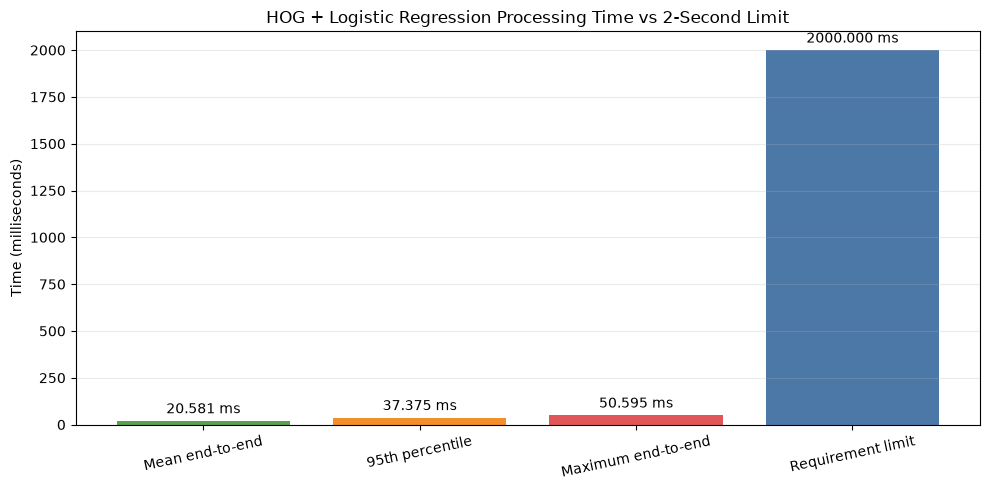

In [14]:
# Figure 2: A readable comparison between the observed mean/maximum times and
# the 2-second requirement. Values are displayed in milliseconds.
comparison_ms = pd.Series({
    "Mean end-to-end": mean_time * 1000,
    "95th percentile": p95_time * 1000,
    "Maximum end-to-end": maximum_time * 1000,
    "Requirement limit": TIME_LIMIT_SECONDS * 1000,
})

colors = ["#59A14F", "#F28E2B", "#E15759", "#4C78A8"]
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(comparison_ms.index, comparison_ms.values, color=colors)
ax.set_ylabel("Time (milliseconds)")
ax.set_title("HOG + Logistic Regression Processing Time vs 2-Second Limit")
ax.grid(axis="y", alpha=0.25)
ax.bar_label(bars, fmt="%.3f ms", padding=3)
plt.xticks(rotation=12)
plt.tight_layout()
plt.show()


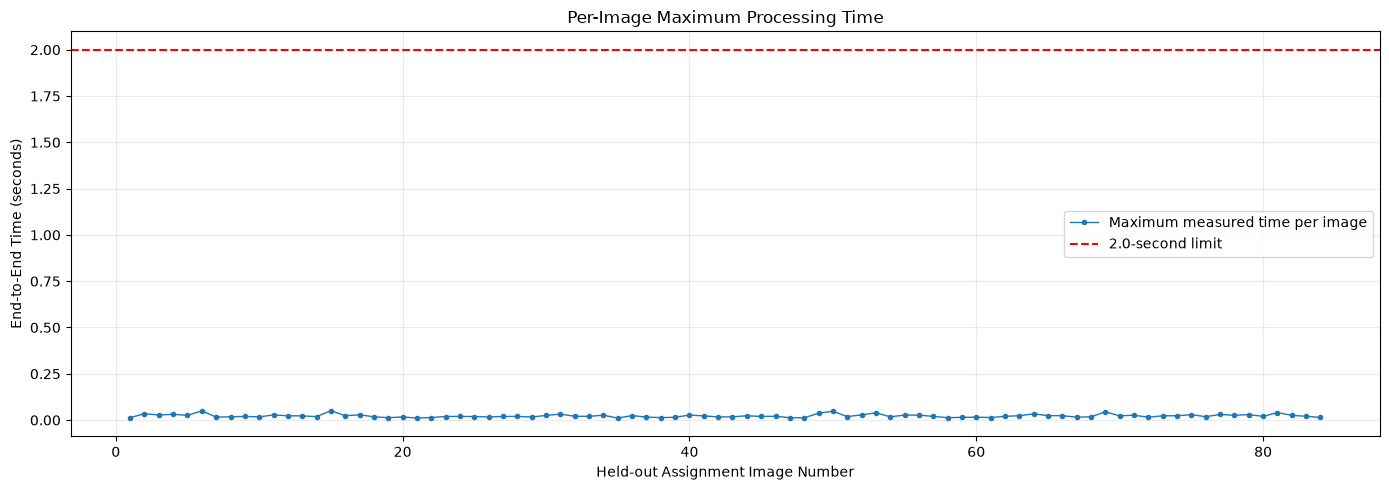

In [15]:
# Figure 3: Maximum measured end-to-end time for each image across all trials.
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(
    per_image_df["Image No."],
    per_image_df["End-to-End Max Time (s)"],
    marker="o",
    markersize=3,
    linewidth=1,
    label="Maximum measured time per image",
)
ax.axhline(
    TIME_LIMIT_SECONDS,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=f"{TIME_LIMIT_SECONDS:.1f}-second limit",
)
ax.set_xlabel("Held-out Assignment Image Number")
ax.set_ylabel("End-to-End Time (seconds)")
ax.set_title("Per-Image Maximum Processing Time")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## 13. Inspect failures or slow images


In [16]:
problem_runs_df = runtime_runs_df.loc[
    runtime_runs_df["Status"].ne("Success")
    | ~runtime_runs_df["Within 2 Seconds"]
    | ~runtime_runs_df["HOG Matches Saved Features"]
].copy()

if problem_runs_df.empty:
    print("No failed, over-limit or HOG-mismatch runs were found.")
else:
    display(problem_runs_df)

print("\nTen slowest successful runs:")
display(
    successful_runs_df.nlargest(10, "End-to-End Time (s)")[[
        "Trial",
        "Image No.",
        "Filename",
        "Predicted Sign",
        "End-to-End Time (s)",
        "Within 2 Seconds",
    ]].style.format({"End-to-End Time (s)": "{:.6f}"})
)


No failed, over-limit or HOG-mismatch runs were found.

Ten slowest successful runs:


,Trial,Image No.,Filename,Predicted Sign,End-to-End Time (s),Within 2 Seconds
98,2,15,047_0005.png,Watch for Trains,0.050595,True
89,2,6,020_0006.png,Go straight or right,0.049895,True
14,1,15,047_0005.png,Watch for Trains,0.048996,True
217,3,50,024_1_0017.png,Go Right,0.047627,True
68,1,69,050_1_0003.png,Watch for fences,0.044966,True
173,3,6,020_0006.png,Go straight or right,0.044343,True
182,3,15,047_0005.png,Watch for Trains,0.043275,True
5,1,6,020_0006.png,Go straight or right,0.040983,True
80,1,81,031_1_0020.png,Uturn allowed,0.040773,True
248,3,81,031_1_0020.png,Uturn allowed,0.039559,True


## 14. Save tables for the report


In [17]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

all_runs_file = OUTPUT_DIR / "hog_logistic_processing_time_all_runs.csv"
per_image_file = OUTPUT_DIR / "hog_logistic_processing_time_per_image.csv"
stage_summary_file = OUTPUT_DIR / "hog_logistic_processing_time_stage_summary.csv"
summary_file = OUTPUT_DIR / "hog_logistic_processing_time_summary.csv"
environment_file = OUTPUT_DIR / "hog_logistic_processing_time_environment.csv"

runtime_runs_df.to_csv(all_runs_file, index=False)
per_image_df.to_csv(per_image_file, index=False)
stage_summary_df.to_csv(stage_summary_file, index=False)
summary_df.to_csv(summary_file, index=False)
environment_df.to_csv(environment_file, index=False)

print("Saved result files:")
for output_file in [
    all_runs_file,
    per_image_file,
    stage_summary_file,
    summary_file,
    environment_file,
]:
    print("-", output_file.resolve())


Saved result files:
- C:\Users\User\OneDrive\Desktop\traffic-sign-recognition\results\hog_logistic_processing_time\hog_logistic_processing_time_all_runs.csv
- C:\Users\User\OneDrive\Desktop\traffic-sign-recognition\results\hog_logistic_processing_time\hog_logistic_processing_time_per_image.csv
- C:\Users\User\OneDrive\Desktop\traffic-sign-recognition\results\hog_logistic_processing_time\hog_logistic_processing_time_stage_summary.csv
- C:\Users\User\OneDrive\Desktop\traffic-sign-recognition\results\hog_logistic_processing_time\hog_logistic_processing_time_summary.csv
- C:\Users\User\OneDrive\Desktop\traffic-sign-recognition\results\hog_logistic_processing_time\hog_logistic_processing_time_environment.csv


## 15. Automatically generated report conclusion


In [18]:
verdict_text = "satisfied" if requirement_passed else "did not satisfy"

conclusion = (
    f"The end-to-end processing-time evaluation was conducted on "
    f"{len(assignment_filenames)} held-out traffic-sign images, with each image "
    f"processed {MEASURED_REPEATS} times. The evaluation included image loading, "
    f"ROI segmentation, HOG feature extraction, feature scaling and Logistic "
    f"Regression prediction. The pipeline achieved a mean processing time of "
    f"{mean_time:.6f} seconds per image, a 95th-percentile time of "
    f"{p95_time:.6f} seconds and a maximum time of {maximum_time:.6f} seconds. "
    f"{within_limit_count} out of {expected_runs} measured runs were completed "
    f"within the 2.000-second limit. Therefore, on the recorded test environment, "
    f"the HOG and Logistic Regression pipeline {verdict_text} the required "
    f"processing time of no more than two seconds per image."
)

print(conclusion)


The end-to-end processing-time evaluation was conducted on 84 held-out traffic-sign images, with each image processed 3 times. The evaluation included image loading, ROI segmentation, HOG feature extraction, feature scaling and Logistic Regression prediction. The pipeline achieved a mean processing time of 0.020581 seconds per image, a 95th-percentile time of 0.037375 seconds and a maximum time of 0.050595 seconds. 252 out of 252 measured runs were completed within the 2.000-second limit. Therefore, on the recorded test environment, the HOG and Logistic Regression pipeline satisfied the required processing time of no more than two seconds per image.
